# Modelos
**Nota: En este caso vamos a trabajar con los datos de el dataset fdrec pero clasificados, osea si va a ser iron o proton**
$$ $$
En este notebook esta planeado para que esten todos los modelos que se van a usar para poder predecir que tipo de particula va tener el rayo estudiado; entonces en esta pequeña introduccion voy a denotar todos los pasos que se haran desde la preparacion de los datos, el entrenamiento de los modelos y el analisis de las metricas, ahora bien echemosle un vistaso a los datos que tenemos en cuestion.


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
fdrec_clasificado=pd.read_csv("fdrec_clasificados.csv")
fdrec_clasificado.head()

,id,gpsnanotime,hdSpectrumEye,hdCalibEye,hdXmaxEye,theta,dtheta,phi,dphi,l,...,cherenkovFraction,minViewAngle,uspL,duspL,uspR,duspR,hottestStationId,distSdpStation,distAxisStation,particle_type
0,1,257161602,0,0,1,48.21,0.38,157.74,0.66,190.73,...,0.08,63.34,229.80,9.60,0.26,0.05,310,54.05,711.71,iron
1,4,278779315,0,0,1,46.34,0.45,255.79,0.68,300.22,...,0.10,31.97,220.66,8.71,0.25,0.05,658,130.63,163.89,iron
2,1,901642884,0,0,1,27.71,0.74,349.57,1.31,244.14,...,0.08,47.52,233.85,8.93,0.25,0.04,246,31.26,608.84,iron
3,1,814732146,0,0,1,45.88,0.40,118.58,0.53,177.78,...,0.11,33.29,231.96,6.35,0.23,0.04,308,285.74,312.06,iron
4,4,166608618,0,0,1,23.81,0.42,34.96,0.99,233.00,...,0.11,44.82,232.43,10.05,0.26,0.05,643,599.18,599.26,iron


In [3]:
fdrec_clasificado=fdrec_clasificado[["theta","phi","dec","totalEnergy","dtotalEnergy","calEnergy","dcalEnergy","xmax"
                        ,"heightXmax","dEdXmax","particle_type","dxmax"]]

In [4]:
fdrec_clasificado.dtypes

theta            float64
phi              float64
dec              float64
totalEnergy      float64
dtotalEnergy     float64
calEnergy        float64
dcalEnergy       float64
xmax             float64
heightXmax       float64
dEdXmax          float64
particle_type     object
dxmax            float64
dtype: object

In [5]:
Cantidad_proton=len(fdrec_clasificado.loc[fdrec_clasificado["particle_type"]=="iron"])
cantidad_iron=len(fdrec_clasificado.loc[fdrec_clasificado["particle_type"]=="proton"])
print(f"la cantidad de datos pertenecientes a un proton es {Cantidad_proton} y la cantidad de registros pertenecientes a un iron es {cantidad_iron}")

la cantidad de datos pertenecientes a un proton es 2716 y la cantidad de registros pertenecientes a un iron es 671


## Analisis preliminar 
Como se puede ver en las tres celdas de codigo anteriores podemos notar algunos aspectos muy importantes y los cuales tendremos que tener en cuenta para poder resolver el problema, el primero es que tenemos un problema de clasificacion binaria donde los posibles resultados son proton o iron, el segundo que todos las columnas del dataframe contienen datos numerocos meno la columna particle_type el cual tiene valores tipo objetos, obstante el dato mas importante es que lamentablemente nuestro problema cae dentro de los problemas de clasificacion desbalanceda, osea que hay muchos mas regritos de una clase que de otra, esto significa que si entrenamos un modelo asi, lo mas probable que pase es que un modelo aprenda a clasificar los registro de una clase, pero los de la otra no va a ser capaz, entonces a la hora de entrenar el modelo tenemos que tener en cuenta esto, ahora bien esto lo podemos solucionar de dos manes, la primera es generar datos de la clase con menos registros y la segunda obcion es que podemos eliminar datos de la clase la cual contenga mas registros y asi valancear las dos clases.

con lo anterior en claro lo que vamos a preceder a hacer es a manipular los datos para poder separar datos de entrenamiento y los datos de testeo

In [6]:
le = LabelEncoder()
y = le.fit_transform(fdrec_clasificado["particle_type"])  # convierte a números

# Separar características (X) y usar la nueva y numérica
X = fdrec_clasificado.drop("particle_type", axis=1)

# División estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
print("Clases codificadas:", list(le.classes_))



Clases codificadas: ['iron', 'proton']


## Modelos seleccionados


Una vez separados los datos vamos a hablar ahora de los modelos que seleccionaremos para resolver el modelo, teniendo en cuenta las caracteristicas mensionada anteriormente

* Arbol de decicion
* Random Forest con ajuste de pesos
* XGBoost con escala de pesos


### Arbol de decicion

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import plot_tree
# Crear el modelo con ajuste al desbalance
tree_clf = DecisionTreeClassifier(
    class_weight='balanced',  # compensa el desbalance
    random_state=42,
    max_depth=3, 
    max_features=None,
    min_samples_split=2,
    min_samples_leaf=5,
    criterion="gini"   
)

# Entrenar
tree_clf.fit(X_train, y_train)

# Predecir
y_pred = tree_clf.predict(X_test)


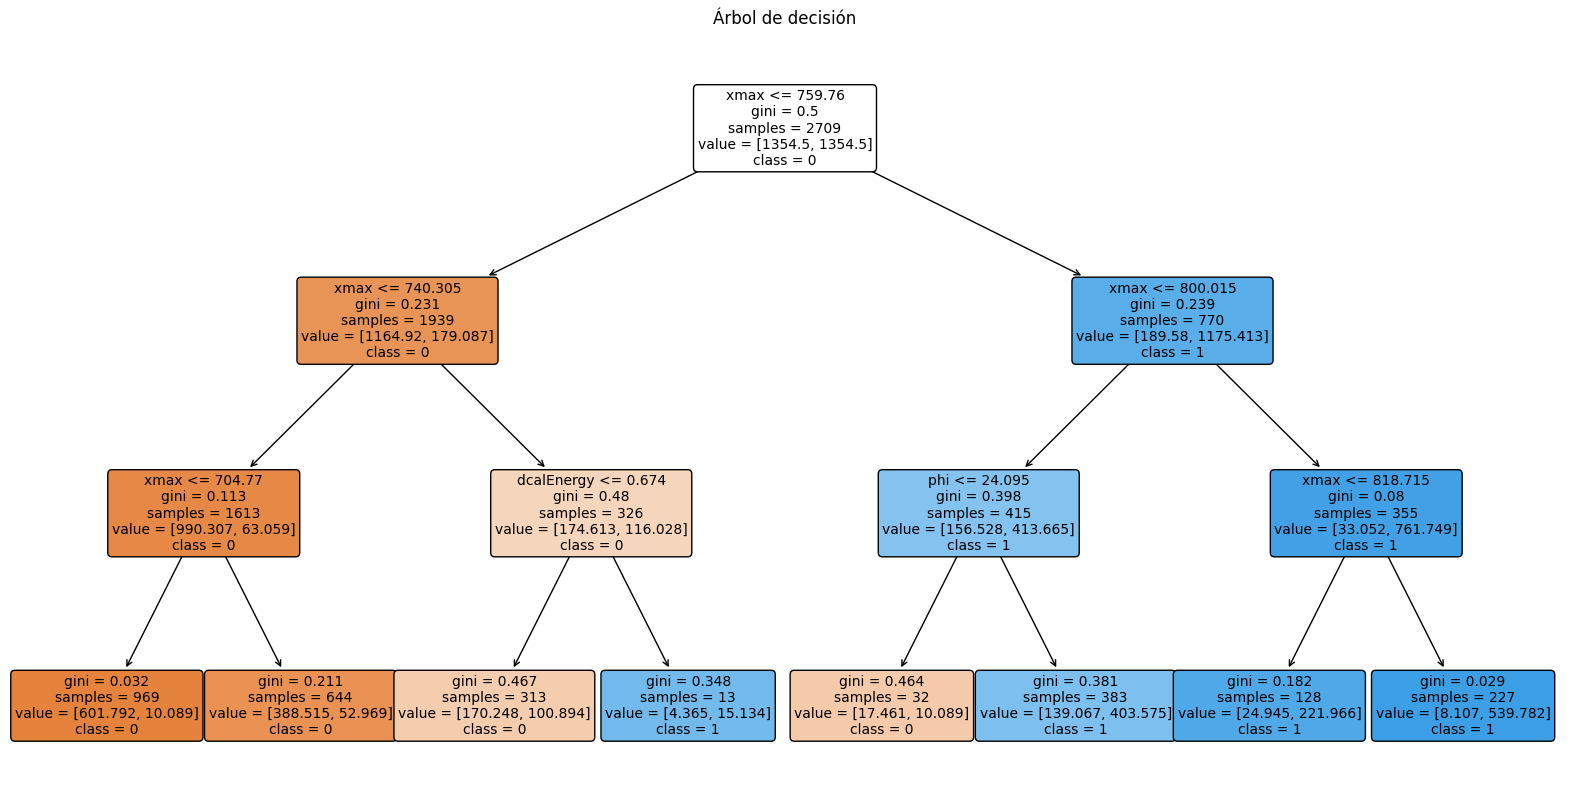

In [8]:
plt.figure(figsize=(20, 10))  # Tamaño ajustable
plot_tree(tree_clf,
            feature_names=X_train.columns,
            class_names=tree_clf.classes_.astype(str),
            filled=True,
            rounded=True,
            fontsize=10)
plt.title("Árbol de decisión")
plt.savefig("images/treedecision_image.png")
plt.show()


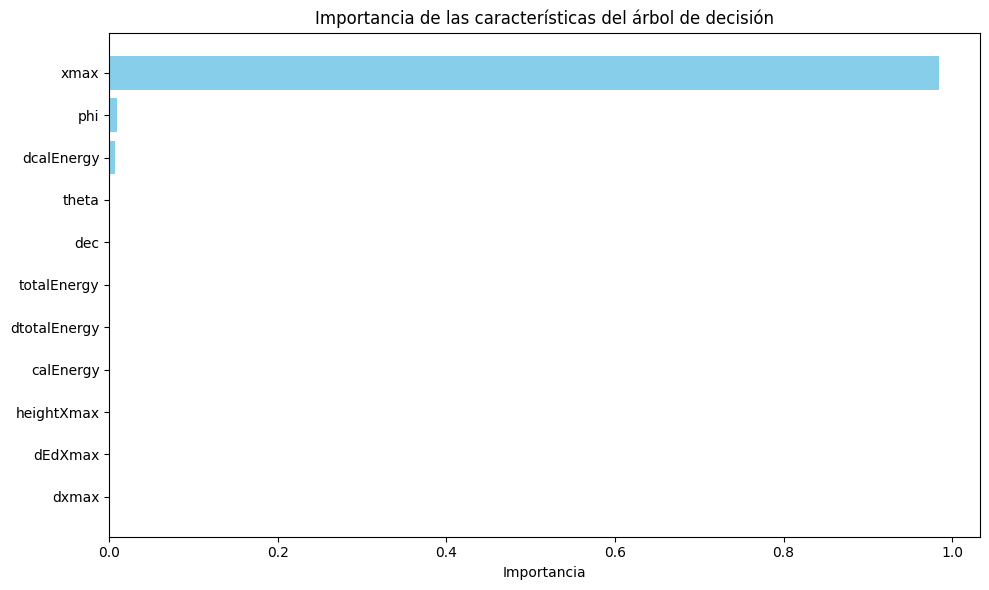

In [9]:
# Obtener las importancias
importances = tree_clf.feature_importances_

# Si X_train es un DataFrame, tomamos los nombres de las columnas
feature_names = X_train.columns

# Crear un DataFrame con las importancias
feat_importances = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Graficar
plt.figure(figsize=(10, 6))
plt.barh(feat_importances['feature'], feat_importances['importance'], color='skyblue')
plt.gca().invert_yaxis()  # Para que las más importantes salgan arriba
plt.xlabel('Importancia')
plt.title('Importancia de las características del árbol de decisión')
plt.tight_layout()
plt.savefig("images/labelImportance_decisionTree.png")
plt.show()

In [10]:
# Evaluar
print("Matriz de confusión:")
confusion_matrix(y_test, y_pred)

Matriz de confusión:


array([[458,  86],
       [ 25, 109]], dtype=int64)

In [11]:
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.95      0.84      0.89       544
           1       0.56      0.81      0.66       134

    accuracy                           0.84       678
   macro avg       0.75      0.83      0.78       678
weighted avg       0.87      0.84      0.85       678



### Random forest

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Crear el modelo Random Forest con peso para clases desbalanceadas
rf_clf = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=100,      # número de árboles
    random_state=42,
    max_depth=None
)

# Entrenar el modelo
rf_clf.fit(X_train, y_train)

# Predecir con el modelo
y_pred = rf_clf.predict(X_test)

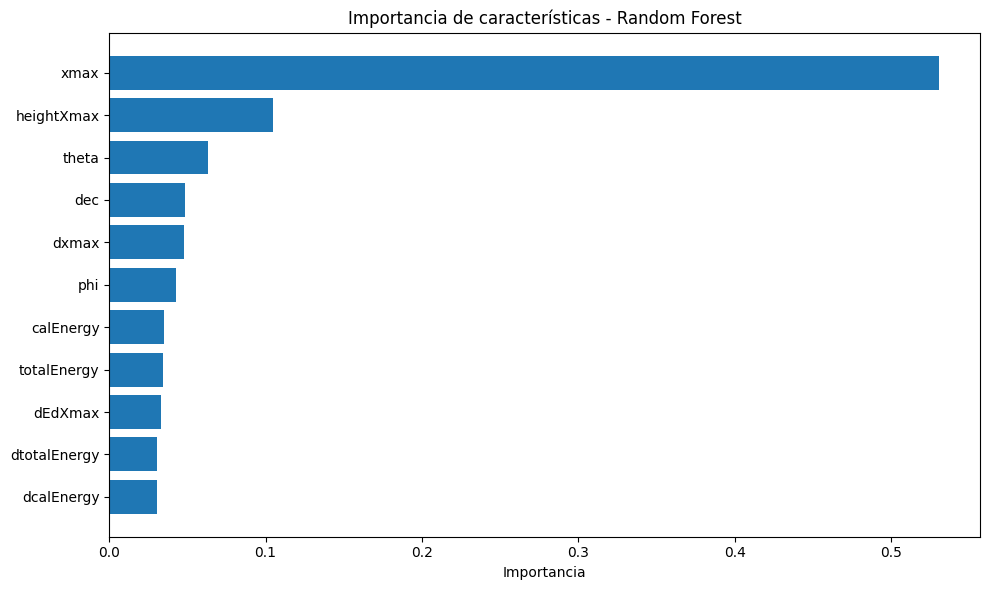

In [13]:
# Supongamos que tienes un DataFrame con nombres de columnas
feature_names = X_train.columns  # Si X_train es un DataFrame

# Obtener importancia de cada feature
importances = rf_clf.feature_importances_

# Crear un DataFrame ordenado
feat_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feat_importances['Feature'], feat_importances['Importance'])
plt.gca().invert_yaxis()  # Opcional: pone la más importante arriba
plt.title('Importancia de características - Random Forest')
plt.xlabel('Importancia')
plt.tight_layout()
plt.savefig("images/labelImportance_randomForest.png")
plt.show()


In [14]:
# Evaluar el modelo
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))


Matriz de confusión:
[[516  28]
 [ 56  78]]


In [15]:
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92       544
           1       0.74      0.58      0.65       134

    accuracy                           0.88       678
   macro avg       0.82      0.77      0.79       678
weighted avg       0.87      0.88      0.87       678



### XGBoost

In [16]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix

# Convertir a DMatrix
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Calcular el peso para la clase minoritaria
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

# Definir parámetros
#{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 100, 'subsample': 0.8}
params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "scale_pos_weight": scale_pos_weight,  # importante para datos desbalanceados
    "eta": 0.1,
    "max_depth": 10,
    "seed": 42,
    'colsample_bytree': 0.8,
    'learning_rate': 0.1,
    'subsample': 0.8
}

# Entrenar el modelo
bst = xgb.train(
    params,
    dtrain,
    num_boost_round=100
)

# Predecir
y_pred_prob = bst.predict(dtest)
y_pred = (y_pred_prob > 0.5).astype(int)


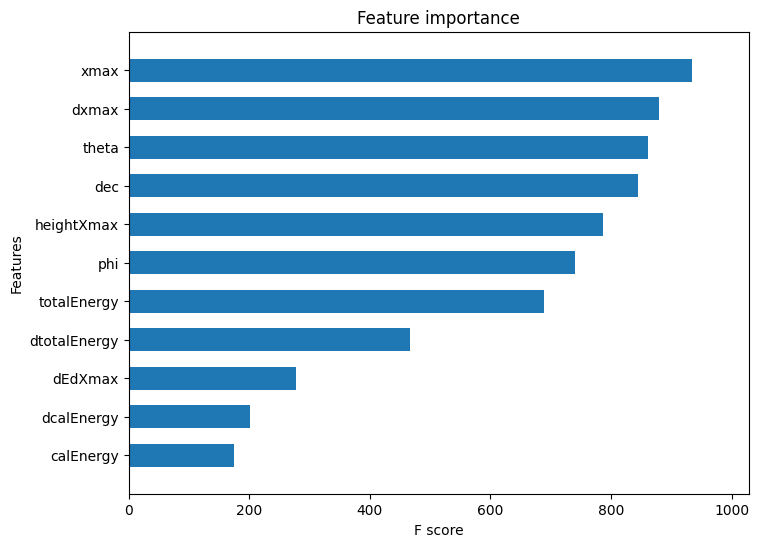

In [25]:
importance = bst.get_score(importance_type='weight')

# Crear figura más grande
fig, ax = plt.subplots(figsize=(8, 6))  # Ajusta el tamaño a tu preferencia
xgb.plot_importance(
    bst,
    importance_type='weight',
    ax=ax,
    show_values=False,   # Quita los valores al frente de las barras
    grid=False,
    height=0.6            # También puedes quitar la grilla desde aquí
)

plt.savefig("images/labelImportance_XGBoost.png")
plt.show()



In [18]:
# Evaluar
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))

Matriz de confusión:
[[501  43]
 [ 44  90]]


In [19]:
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       544
           1       0.68      0.67      0.67       134

    accuracy                           0.87       678
   macro avg       0.80      0.80      0.80       678
weighted avg       0.87      0.87      0.87       678

